# 📊 Lesson 04 · 员工分析工作流（并行汇聚）

> **Fan-out / Fan-in**：年薪 / 奖金 / 项目评估从 `START` 并行扇出，再汇入 `summary`。

本课你会学到：
- 多条边从同一节点出发实现并行
- 汇聚节点如何读取并行上游写入的字段
- **不调用 LLM**，专注 State / Node / Edge 与并行编排

本例是纯函数计算，方便看清并行控制流。


# 导入

引入 StateGraph 与 TypedDict。本例不调用 LLM。


In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

C:\Users\86137\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\triton\windows_utils.py:372: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")


# 定义 State

入口字段由 `invoke` 传入；`yearly_salary` / `bonus_amount` / `project_status` / `summary` 由各节点写入。


In [2]:
# Define State
class EmployeeState(TypedDict):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str


# 节点 1 — 计算年薪

`monthly_salary * 12` → `yearly_salary`。


In [3]:
# # Node 1 - Calculate Yearly Salary

def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state['monthly_salary'] * 12
  
    return {
        'yearly_salary': yearly_salary
    }


# 节点 2 — 计算奖金

按月薪估算奖金，写入 `bonus_amount`。


In [4]:
# Node 2 - Calculate Bonus
def calculate_bonus(state: EmployeeState):
    bonus_amount = state['monthly_salary'] * 2
    return {
        'bonus_amount': bonus_amount
    }


# 节点 3 — 项目评估

按完成项目数打出 `project_status`。


In [5]:
# Node 3 - Project Evaluation

def project_evaluation(state: EmployeeState):
    if state['completed_projects'] >= 5:
        status = 'Excellent'
    else:
        status = 'Average'

    return {
        'project_status': status
    }

# 汇聚节点 — summary

读取并行上游结果，拼成一段 `summary` 文本。


In [6]:
# Summary Node
def summary(state: EmployeeState):
    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and a bonus of {state['bonus_amount']}. Project status is {state['project_status']}."
    return {
        'summary': summary_text
    }



## 逻辑总览

```mermaid
%%{init: {
  "theme": "base",
  "themeVariables": {
    "fontSize": "13px",
    "fontFamily": "ui-sans-serif, system-ui",
    "primaryTextColor": "#0f172a",
    "lineColor": "#94a3b8"
  }
}}%%
flowchart TB
    S([START]) --> Y[calculate_yearly_salary]
    S --> B[calculate_bonus]
    S --> P[project_evaluation]
    Y --> SU[summary]
    B --> SU
    P --> SU
    SU --> E([END])


    classDef input fill:#BFDBFE,stroke:#3B82F6,color:#1E3A8A,stroke-width:2px
    classDef llm fill:#FED7AA,stroke:#F97316,color:#9A3412,stroke-width:2px
    classDef branch fill:#E9D5FF,stroke:#A855F7,color:#6B21A8,stroke-width:2px
    classDef tool fill:#BBF7D0,stroke:#22C55E,color:#14532D,stroke-width:2px
    classDef output fill:#FECACA,stroke:#F87171,color:#7F1D1D,stroke-width:2px
    class S input
    class Y,B,P,SU tool
    class E output
```




In [7]:
# Create Graph

graph = StateGraph(EmployeeState)

# Add Nodes

graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('calculate_bonus', calculate_bonus)
graph.add_node('project_evaluation', project_evaluation)
graph.add_node('summary', summary)

# Add Edges
graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'project_evaluation')

graph.add_edge('calculate_yearly_salary', 'summary')
graph.add_edge('calculate_bonus', 'summary')
graph.add_edge('project_evaluation', 'summary')

graph.add_edge('summary', END)



# Compile Workflow

workflow = graph.compile()

# 可视化图结构

核对 fan-out / fan-in 是否正确。


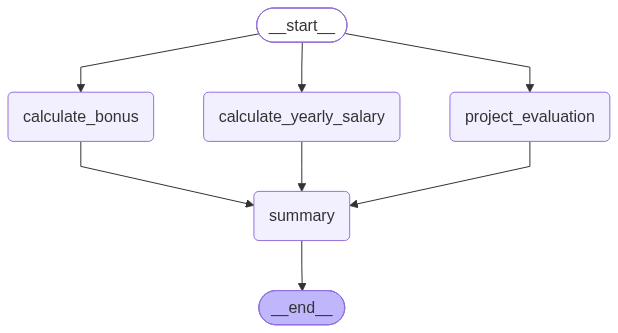

In [8]:
workflow

# 执行图

传入员工信息，查看并行计算与汇总结果。


In [9]:
# Initial Input

initial_state = {
    'employee_name': 'Bappy',
    'monthly_salary': 50000,
    'working_days': 26,
    'completed_projects': 7
}

# Run Workflow

result = workflow.invoke(initial_state)

# 查看结果


In [10]:
result

{'employee_name': 'Bappy',
 'monthly_salary': 50000,
 'working_days': 26,
 'completed_projects': 7,
 'yearly_salary': 600000,
 'bonus_amount': 100000,
 'project_status': 'Excellent',
 'summary': 'Employee Bappy has a yearly salary of 600000 and a bonus of 100000. Project status is Excellent.'}